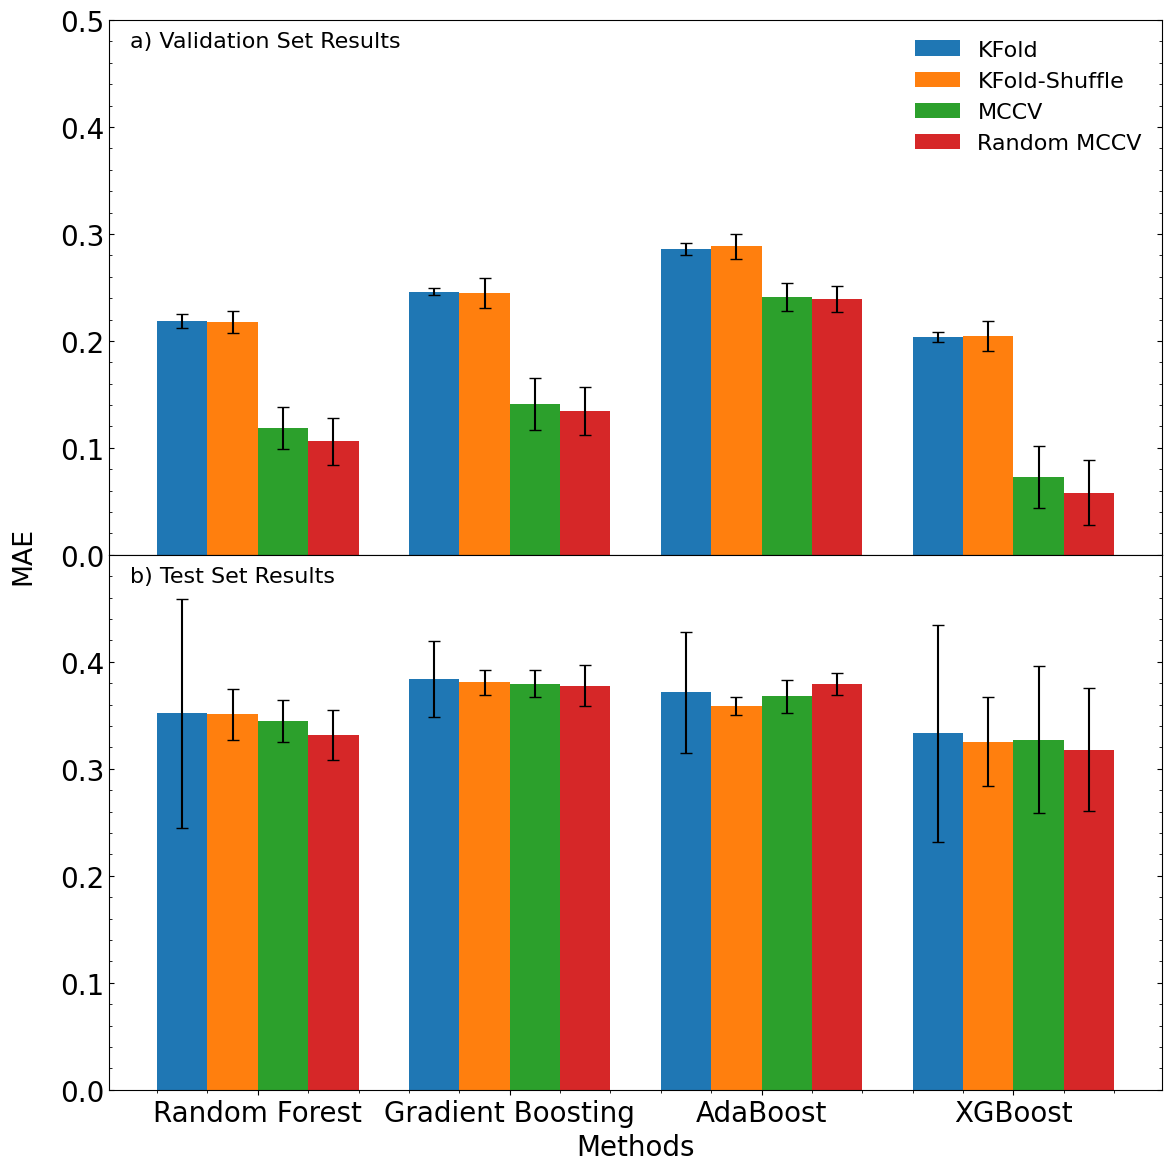

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, ShuffleSplit
import random

#### Font Sizing
#SMALL_SIZE =12
#MEDIUM_SIZE = 15
#BIGGER_SIZE = 18
SMALL_SIZE =16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
#### 

# Set random seed for reproducibility
np.random.seed(0)
random.seed(0)
seed=0

# Define parameter grids for each model (placeholder)
rf_param_grid = {}
gb_param_grid = {}
adaboost_param_grid = {}
xgb_param_grid = {}
catboost_param_grid = {}

# Initialize models
models = {
    'Random Forest': (RandomForestRegressor(random_state=seed), rf_param_grid),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=seed), gb_param_grid),
    'AdaBoost': (AdaBoostRegressor(random_state=seed), adaboost_param_grid),
    'XGBoost': (XGBRegressor(random_state=seed, use_label_encoder=False, eval_metric='mae'), xgb_param_grid),
}

# Define cross-validation strategies
cv_methods = {
    'KFold': KFold(n_splits=4),
    'KFold-Shuffle': KFold(n_splits=4, shuffle=True, random_state=seed),
    'MCCV': ShuffleSplit(n_splits=4, test_size=0.25, random_state=seed),
    'Random MCCV': ShuffleSplit(n_splits=4, test_size=random.uniform(0.1, 0.25), random_state=seed)
}

# --- Helper function to load and process data ---
def load_and_process_results(filename, models_keys, cv_methods_keys):
    """Loads CSV, calculates mean/std, and re-orders."""
    results_df = pd.read_csv(filename)
    
    # Group by Model and CV_Method to get stats
    grouped_results = results_df.groupby(['Model', 'CV_Method'])['MAE']
    average_results = grouped_results.mean().unstack()
    std_dev_results = grouped_results.std().unstack()

    # Re-order rows and columns to match the defined dictionary orders
    average_results = average_results.reindex(index=models_keys, columns=cv_methods_keys)
    std_dev_results = std_dev_results.reindex(index=models_keys, columns=cv_methods_keys)
    
    return average_results, std_dev_results

# --- Load and process Validation data ---
val_average, val_std_dev = load_and_process_results(
    'standard_method_val_10_results.csv', 
    models.keys(), 
    cv_methods.keys()
)

# --- Load and process Test data ---
test_average, test_std_dev = load_and_process_results(
    'standard_method_test_10_results.csv', 
    models.keys(), 
    cv_methods.keys()
)


# --- Setup the plot ---
# Create 2 subplots, stacked vertically (2 rows, 1 column)
# Share the X-axis for consistency
# Add gridspec_kw={'hspace': 0} to remove vertical spacing
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True, 
                            gridspec_kw={'hspace': 0})
plt.rcParams["mathtext.fontset"] = "cm"

# MODIFICATION: Remove the 'fig.supylabel('MAE')' call from here
# It will be added just before tight_layout

bar_width = 0.20
index = np.arange(len(models)) # index based on number of models

# --- Plot 1: Validation Set (Top) ---
# Place 'a)' in the top-left *inside* the axes
ax1.text(0.02, 0.98, 'a) Validation Set Results', 
         transform=ax1.transAxes,  
         va='top', ha='left') 

for i, method_name in enumerate(cv_methods.keys()):
    avg_scores = val_average[method_name]
    std_scores = val_std_dev[method_name]
    ax1.bar(index + i * bar_width, 
            avg_scores, 
            bar_width, 
            label=method_name, 
            yerr=std_scores, 
            capsize=4) 

ax1.minorticks_on()
ax1.tick_params(axis='y', left=True, right=True, direction='in', which='both')
ax1.set_ylim(0, 0.5)  
ax1.set_yticks(np.arange(0, 0.6, 0.1))
ax1.legend(loc='upper right', frameon=False) 

# --- Plot 2: Test Set (Bottom) ---
# Place 'b)' in the top-left *inside* the axes
ax2.text(0.02, 0.98, 'b) Test Set Results', 
         transform=ax2.transAxes, 
         va='top', ha='left')

for i, method_name in enumerate(cv_methods.keys()):
    avg_scores = test_average[method_name]
    std_scores = test_std_dev[method_name]
    ax2.bar(index + i * bar_width, 
            avg_scores, 
            bar_width, 
            label=method_name, 
            yerr=std_scores, 
            capsize=4)

ax2.set_xlabel('Methods')
ax2.minorticks_on()
ax2.tick_params(axis='y', left=True, right=True, direction='in', which='both')
ax2.set_ylim(0, 0.5)  
ax2.set_yticks(np.arange(0, 0.5, 0.1)) # Ticks from 0.0 to 0.4

ax2.set_xticks(index + bar_width * (len(cv_methods) - 1) / 2)
ax2.set_xticklabels(models.keys(), rotation=0)

# --- Finalize and Save ---

# MODIFICATION: Add the supylabel and store its object *before* tight_layout
mae_label = fig.supylabel('MAE')

# Run tight_layout to calculate final positions
plt.tight_layout() 

# MODIFICATION: Manually adjust the MAE label position
# Get the y-coordinate of the shared border (bottom of ax1)
# This must be done *after* tight_layout()
border_y_coord = ax1.get_position().y0 

# Set the label's y-position to the border coordinate
mae_label.set_y(border_y_coord)

# Set the vertical alignment to 'center'
# This centers the text *on* that coordinate
mae_label.set_verticalalignment('center') 

plt.savefig('combine_ML_methods_10.pdf', dpi=300) 
plt.show()